# Implementación y entrenamiento de una LSTM

Este notebook implementa una red LSTM para predecir la concentración horaria de PM2.5. Se mantiene el mismo protocolo temporal utilizado en la línea base: ventanas de 24 horas, horizonte de predicción de 1 hora, normalización calculada con el conjunto de entrenamiento y particiones temporales de entrenamiento, validación y prueba.

Se entrenan y comparan dos variantes de la arquitectura, con 64 y 32 unidades ocultas. El objetivo es comprobar si aumentar la capacidad de la red produce una mejora relevante sin modificar el resto de las condiciones experimentales.

## 1. Entorno y reproducibilidad

Se importan las librerías necesarias y se fija una semilla aleatoria común para NumPy y PyTorch. Esto permite repetir el experimento bajo las mismas condiciones y facilita la comparación entre las dos configuraciones de la LSTM.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 8
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__)
print("Semilla fijada:", SEED)

torch: 2.13.0
Semilla fijada: 8


## 2. Carga de datos y configuración temporal

Se cargan los tensores preparados en el notebook anterior para la configuración `A_24h_a_1h`. Cada ejemplo contiene 24 horas consecutivas y la variable objetivo corresponde a PM2.5 una hora después. También se recuperan la media y la desviación estándar del conjunto de entrenamiento para expresar las métricas finales en la escala original de µg/m³.

In [2]:
FEATURES = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
            "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TARGET = "PM2.5"
IDX_TARGET = FEATURES.index(TARGET)

PYTORCH_DIR_PATH = Path("data/pytorch_tensors")
CLEANED_DATA_DIR = Path("data/processed")

# Se elige la configuración A (24h -> 1h) como configuración principal para
# entrenar la LSTM, por ser la de horizonte más corto y mayor volumen de datos.
CONFIG = "A_24h_a_1h"
WINDOW, HORIZON = 24, 1

d_train = torch.load(PYTORCH_DIR_PATH / f"{CONFIG}_train.pt")
d_val = torch.load(PYTORCH_DIR_PATH / f"{CONFIG}_val.pt")
d_test = torch.load(PYTORCH_DIR_PATH / f"{CONFIG}_test.pt")

X_train, y_train = d_train["X"], d_train["y"]
X_val, y_val = d_val["X"], d_val["y"]
X_test, y_test = d_test["X"], d_test["y"]

print(f"Train: X {tuple(X_train.shape)} | y {tuple(y_train.shape)}")
print(f"Val:   X {tuple(X_val.shape)} | y {tuple(y_val.shape)}")
print(f"Test:  X {tuple(X_test.shape)} | y {tuple(y_test.shape)}")

# Recuperar media/desviación de PM2.5 (train) para des-normalizar más adelante
train_raw = pd.read_csv(CLEANED_DATA_DIR / "train.csv", parse_dates=["datetime"])
media_pm25 = train_raw["PM2.5"].mean()
desv_pm25 = train_raw["PM2.5"].std()

def desnormalizar(valor_z):
    return valor_z * desv_pm25 + media_pm25

Train: X (315360, 24, 11) | y (315360,)
Val:   X (52704, 24, 11) | y (52704,)
Test:  X (51840, 24, 11) | y (51840,)


## 3. Construcción de los conjuntos de datos

Los tensores se convierten en `TensorDataset` y se organizan mediante `DataLoader`. El entrenamiento utiliza `shuffle=True` para cambiar el orden de los ejemplos completos, mientras que validación y prueba conservan un orden fijo. La aleatorización no altera el orden temporal interno de ninguna ventana.

In [3]:
BATCH_SIZE = 256

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 4. Arquitectura de la LSTM

La red recibe una secuencia de 24 observaciones y 11 variables por instante. La capa LSTM procesa la secuencia y utiliza el estado oculto final de la última capa como resumen de la ventana; una capa lineal transforma ese resumen en una predicción escalar de PM2.5. Se comparan dos tamaños del estado oculto, 64 y 32 unidades, manteniendo fija la arquitectura restante.

In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, ventana, n_features)
        out, (h_n, c_n) = self.lstm(x)
        ultimo_estado = h_n[-1]  # (batch, hidden_size), estado final de la última capa
        return self.fc(ultimo_estado).squeeze(-1)  # (batch,)


N_FEATURES = X_train.shape[2]
NUM_LAYERS = 1

print(f"Características de entrada: {N_FEATURES}")
print(f"Número de capas LSTM: {NUM_LAYERS}")

Características de entrada: 11
Número de capas LSTM: 1


## 5. Hiperparámetros y función objetivo

Se utiliza el error cuadrático medio (`MSELoss`) sobre los valores normalizados. Los pesos se optimizan con Adam y una tasa de aprendizaje de `1e-3`. El entrenamiento se limita a 50 épocas, con lotes de 256 ejemplos y parada temprana después de cinco épocas sin mejora en validación.

In [5]:
LEARNING_RATE = 1e-3
MAX_EPOCHS = 50
PATIENCE = 5  # épocas sin mejora en validación antes de detener

criterio = nn.MSELoss()

print("Hiperparámetros:")
print(f"  Arquitecturas: LSTM con HIDDEN_SIZE en {{64, 32}}")
print(f"  Función de pérdida: MSELoss")
print(f"  Optimizador: Adam, lr={LEARNING_RATE}")
print(f"  Épocas máximas: {MAX_EPOCHS}, patience (early stopping): {PATIENCE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Semilla: {SEED}")

Hiperparámetros:
  Arquitecturas: LSTM con HIDDEN_SIZE en {64, 32}
  Función de pérdida: MSELoss
  Optimizador: Adam, lr=0.001
  Épocas máximas: 50, patience (early stopping): 5
  Batch size: 256
  Semilla: 8


## 6. Entrenamiento con parada temprana

La función `entrenar_lstm` crea una red y un optimizador nuevos para cada tamaño del estado oculto. Durante cada época calcula la pérdida de entrenamiento y validación, conserva una copia de los mejores pesos y detiene la ejecución cuando la validación deja de mejorar. Al finalizar, se restauran los pesos de la mejor época.

In [6]:
def entrenar_lstm(hidden_size):
    torch.manual_seed(SEED)
    modelo = LSTMForecaster(
        n_features=N_FEATURES,
        hidden_size=hidden_size,
        num_layers=NUM_LAYERS,
    )
    optimizador = torch.optim.Adam(modelo.parameters(), lr=LEARNING_RATE)
    historial = {"train_loss": [], "val_loss": []}
    mejor_val_loss = float("inf")
    epocas_sin_mejora = 0
    mejor_estado = None

    for epoca in range(1, MAX_EPOCHS + 1):
        modelo.train()
        perdida_train_total = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            pred = modelo(X_batch)
            perdida = criterio(pred, y_batch)
            perdida.backward()
            optimizador.step()
            perdida_train_total += perdida.item() * X_batch.size(0)
        perdida_train = perdida_train_total / len(train_ds)

        modelo.eval()
        perdida_val_total = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred = modelo(X_batch)
                perdida = criterio(pred, y_batch)
                perdida_val_total += perdida.item() * X_batch.size(0)
        perdida_val = perdida_val_total / len(val_ds)

        historial["train_loss"].append(perdida_train)
        historial["val_loss"].append(perdida_val)
        print(
            f"HIDDEN_SIZE={hidden_size:02d} | época {epoca:02d} | "
            f"train_loss={perdida_train:.4f} | val_loss={perdida_val:.4f}"
        )

        if perdida_val < mejor_val_loss:
            mejor_val_loss = perdida_val
            epocas_sin_mejora = 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= PATIENCE:
                print(f"Parada temprana en la época {epoca}.")
                break

    modelo.load_state_dict(mejor_estado)
    print(f"Mejor val_loss ({hidden_size} unidades): {mejor_val_loss:.4f}")
    return modelo, historial, mejor_val_loss


modelos = {}
historiales = {}
for hidden_size in (64, 32):
    modelos[hidden_size], historiales[hidden_size], _ = entrenar_lstm(hidden_size)

# Se mantiene la variante de 64 unidades como modelo principal para las gráficas posteriores.
HIDDEN_SIZE = 64
modelo = modelos[HIDDEN_SIZE]
historial = historiales[HIDDEN_SIZE]
n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"\nModelo seleccionado: HIDDEN_SIZE={HIDDEN_SIZE}, parámetros={n_parametros:,}")

HIDDEN_SIZE=64 | época 01 | train_loss=0.0818 | val_loss=0.0319
HIDDEN_SIZE=64 | época 02 | train_loss=0.0494 | val_loss=0.0300
HIDDEN_SIZE=64 | época 03 | train_loss=0.0478 | val_loss=0.0300
HIDDEN_SIZE=64 | época 04 | train_loss=0.0468 | val_loss=0.0300
HIDDEN_SIZE=64 | época 05 | train_loss=0.0459 | val_loss=0.0304
HIDDEN_SIZE=64 | época 06 | train_loss=0.0451 | val_loss=0.0296
HIDDEN_SIZE=64 | época 07 | train_loss=0.0446 | val_loss=0.0304
HIDDEN_SIZE=64 | época 08 | train_loss=0.0439 | val_loss=0.0297
HIDDEN_SIZE=64 | época 09 | train_loss=0.0434 | val_loss=0.0309
HIDDEN_SIZE=64 | época 10 | train_loss=0.0429 | val_loss=0.0298
HIDDEN_SIZE=64 | época 11 | train_loss=0.0425 | val_loss=0.0303
Parada temprana en la época 11.
Mejor val_loss (64 unidades): 0.0296
HIDDEN_SIZE=32 | época 01 | train_loss=0.0942 | val_loss=0.0310
HIDDEN_SIZE=32 | época 02 | train_loss=0.0500 | val_loss=0.0305
HIDDEN_SIZE=32 | época 03 | train_loss=0.0486 | val_loss=0.0312
HIDDEN_SIZE=32 | época 04 | train_l

## 7. Curvas de entrenamiento y validación

La pérdida de entrenamiento disminuye progresivamente, mientras que la pérdida de validación se mantiene prácticamente estable. No se observan señales claras de sobreajuste.

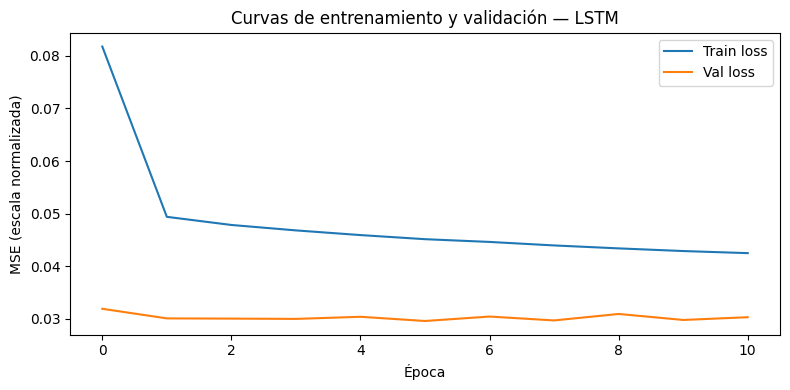

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historial["train_loss"], label="Train loss")
ax.plot(historial["val_loss"], label="Val loss")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (escala normalizada)")
ax.set_title("Curvas de entrenamiento y validación — LSTM")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Evaluación en el conjunto de prueba

Las predicciones se desnormalizan antes de calcular RMSE y MAE, de modo que los resultados se expresan en µg/m³ y se pueden interpretar directamente. Se evalúan las dos variantes sobre exactamente las mismas ventanas de prueba.

In [8]:
y_test_desnorm = desnormalizar(y_test)
metricas_lstm = []
predicciones_por_tamano = {}

for hidden_size, modelo_variante in modelos.items():
    modelo_variante.eval()
    predicciones = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            predicciones.append(modelo_variante(X_batch))
    pred_test = torch.cat(predicciones)
    pred_test_real = desnormalizar(pred_test)
    predicciones_por_tamano[hidden_size] = pred_test_real
    rmse = torch.sqrt(torch.mean((pred_test_real - y_test_desnorm) ** 2)).item()
    mae = torch.mean(torch.abs(pred_test_real - y_test_desnorm)).item()
    metricas_lstm.append({"modelo": f"LSTM ({hidden_size})", "RMSE": rmse, "MAE": mae})
    print(f"LSTM ({hidden_size}) — Test RMSE: {rmse:.2f} µg/m³ | MAE: {mae:.2f} µg/m³")

# Variables de la variante de 64 para las gráficas posteriores.
pred_test_real = predicciones_por_tamano[64]
rmse_lstm = next(m["RMSE"] for m in metricas_lstm if m["modelo"] == "LSTM (64)")
mae_lstm = next(m["MAE"] for m in metricas_lstm if m["modelo"] == "LSTM (64)")

LSTM (64) — Test RMSE: 20.47 µg/m³ | MAE: 10.60 µg/m³
LSTM (32) — Test RMSE: 20.56 µg/m³ | MAE: 10.58 µg/m³


## 9. Comparación con las líneas base

La tabla reúne las métricas de la LSTM y de las líneas base naïve simple y naïve estacional para la configuración `A_24h_a_1h`. Esta comparación permite distinguir la mejora debida al aprendizaje de patrones temporales de la que se obtiene al utilizar directamente valores anteriores.

In [9]:
RESULTADOS_DIR = Path("results")

resultados_baseline = pd.read_csv(RESULTADOS_DIR / "resultados_lineas_base.csv")
fila_baseline_test = resultados_baseline[
    (resultados_baseline["configuracion"] == CONFIG) &
    (resultados_baseline["conjunto"] == "test")
]

tabla_comparativa = pd.concat([
    fila_baseline_test[["linea_base", "RMSE", "MAE"]].rename(columns={"linea_base": "modelo"}),
    pd.DataFrame(metricas_lstm),
], ignore_index=True)

print(tabla_comparativa.to_string(index=False))
tabla_comparativa.to_csv("comparacion_lstm_vs_baseline.csv", index=False)

          modelo       RMSE       MAE
    naive_simple  22.880000 11.450000
naive_estacional 105.220000 71.360000
       LSTM (64)  20.468607 10.603110
       LSTM (32)  20.560116 10.575063


## 10. Visualización de predicciones y errores

La figura muestra las primeras 200 horas del conjunto de prueba y permite observar tanto la trayectoria predicha como el error de cada instante. La LSTM sigue adecuadamente la tendencia general del PM2.5 y captura variaciones progresivas. Su principal dificultad aparece ante cambios muy bruscos y aislados, que son difíciles de anticipar utilizando únicamente las 24 horas anteriores.

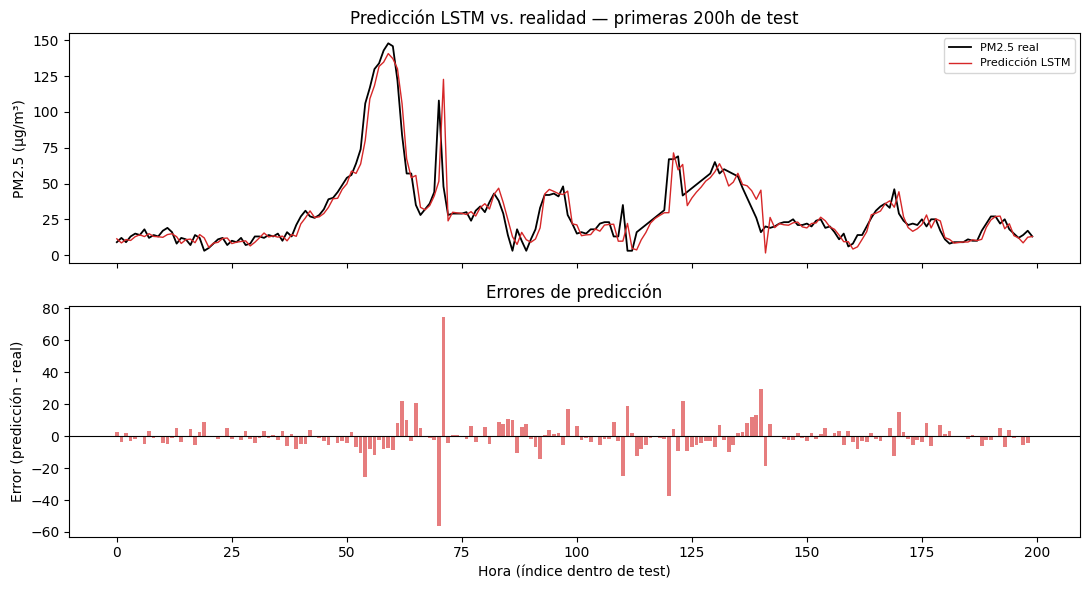

In [11]:
n_mostrar = 200

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(y_test_desnorm[:n_mostrar].numpy(), label="PM2.5 real", color="black", linewidth=1.3)
axes[0].plot(pred_test_real[:n_mostrar].numpy(), label="Predicción LSTM", color="tab:red", linewidth=1)
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_title("Predicción LSTM vs. realidad — primeras 200h de test")
axes[0].legend(fontsize=8)

errores = (pred_test_real[:n_mostrar] - y_test_desnorm[:n_mostrar]).numpy()
axes[1].bar(range(n_mostrar), errores, color="tab:red", alpha=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Error (predicción - real)")
axes[1].set_xlabel("Hora (índice dentro de test)")
axes[1].set_title("Errores de predicción")

plt.tight_layout()
plt.show()

## 11. Conclusiones

Las variantes de 32 y 64 unidades obtuvieron resultados prácticamente iguales en validación, con errores de 0.0298 y 0.0296, respectivamente. Se selecciona la configuración de 64 unidades porque presenta el menor error, aunque la diferencia es mínima y no demuestra una ventaja sustancial frente al modelo más pequeño.

En el conjunto de prueba la LSTM de 64 unidades obtiene un RMSE de 20.47 µg/m³ y un MAE de 10.60 µg/m³. La variante de 32 unidades obtiene un RMSE de 20.56 µg/m³ y un MAE de 10.58 µg/m³. Por tanto, ambas arquitecturas tienen un comportamiento muy similar; la de 64 unidades mejora ligeramente el RMSE, mientras que la de 32 unidades presenta un MAE marginalmente menor.

En la comparación con la línea base se puede tomar como referencia la variante de 32 unidades, que obtiene un RMSE de 20.56 µg/m³ y un MAE de 10.58 µg/m³, frente a los 22.88 µg/m³ y 11.45 µg/m³ de la línea base naïve simple. La mejora es moderada, alrededor del 10 % en RMSE, pero muestra que la LSTM aporta capacidad predictiva adicional frente a utilizar únicamente el valor de la hora anterior. La variante de 64 unidades ofrece una reducción de RMSE ligeramente mayor, aunque con un MAE algo superior.

En conjunto el modelo resulta útil para seguir la tendencia y las variaciones progresivas, pero conserva limitaciones ante eventos repentinos.
